In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor  # Direct import, no need for experimental module
from sklearn.metrics import median_absolute_error, roc_auc_score
from sklearn.model_selection import KFold, train_test_split
from matplotlib.patches import ConnectionPatch
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
df_train = pd.read_csv("C:/Users/Dell/Desktop/Projects/Loan approval prediction/Dataset/train.csv")
df_test  = pd.read_csv("C:/Users/Dell/Desktop/Projects/Loan approval prediction/Dataset/test.csv")
df_sub   = pd.read_csv("C:/Users/Dell/Desktop/Projects/Loan approval prediction/Dataset/sample_submission.csv")

In [3]:
df_origi = pd.read_csv("C:/Users/Dell/Desktop/Projects/Loan approval prediction/Dataset/credit_risk_dataset.csv")

In [4]:
df_origi.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df_origi.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [6]:
df_origi.shape

(32581, 12)

In [7]:
df_train.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [8]:
df_train.shape

(58645, 13)

In [9]:
df_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [10]:
df_train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [11]:
df_test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [12]:
df_sub.head()

,id,loan_status
0,58645,0.5
1,58646,0.5
2,58647,0.5
3,58648,0.5
4,58649,0.5


In [13]:
df_train = df_train.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

In [14]:
df_train.shape,df_test.shape

((58645, 12), (39098, 11))

In [15]:
df_train = pd.concat([df_train,df_origi],axis=0)

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91226 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  91226 non-null  int64  
 1   person_income               91226 non-null  int64  
 2   person_home_ownership       91226 non-null  object 
 3   person_emp_length           90331 non-null  float64
 4   loan_intent                 91226 non-null  object 
 5   loan_grade                  91226 non-null  object 
 6   loan_amnt                   91226 non-null  int64  
 7   loan_int_rate               88110 non-null  float64
 8   loan_percent_income         91226 non-null  float64
 9   cb_person_default_on_file   91226 non-null  object 
 10  cb_person_cred_hist_length  91226 non-null  int64  
 11  loan_status                 91226 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 9.0+ MB


In [17]:
df_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

In [18]:
df_test.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [19]:
df_train['person_emp_length'] = df_train['person_emp_length'].fillna(df_train['person_emp_length'].mean())
df_train['loan_int_rate'] = df_train['loan_int_rate'].fillna(df_train['loan_int_rate'].mean())

In [20]:
df_train.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

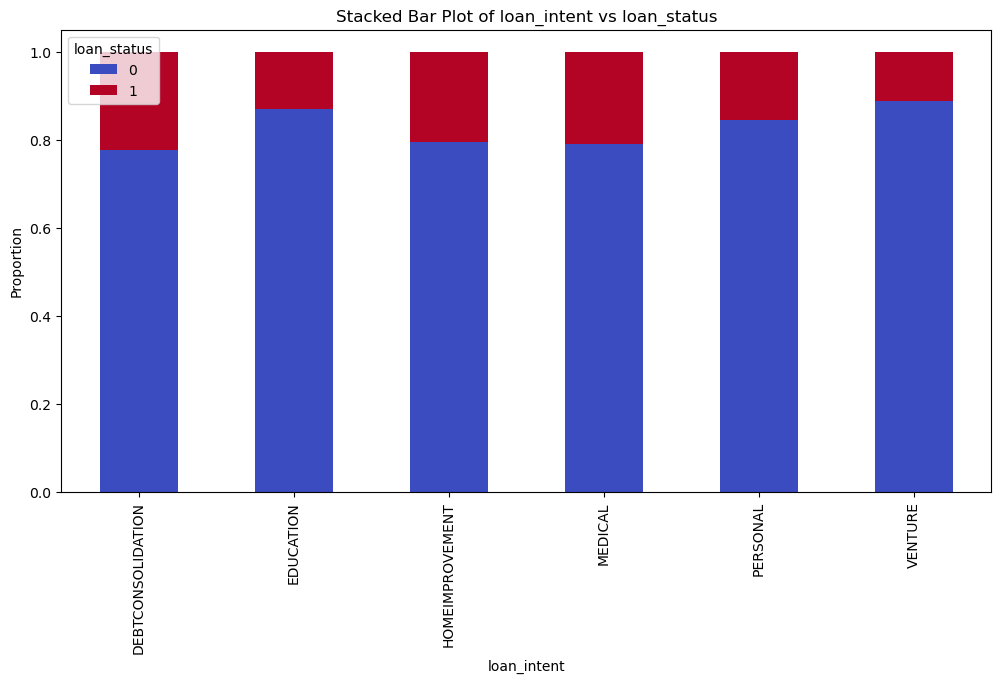

In [21]:
def stacked_bar_plot(df, feature, target='loan_status'):
    crosstab = pd.crosstab(df[feature], df[target], normalize='index')
    crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='coolwarm')
    plt.title(f'Stacked Bar Plot of {feature} vs {target}')
    plt.ylabel('Proportion')
    plt.show()
stacked_bar_plot(df_train, 'loan_intent')

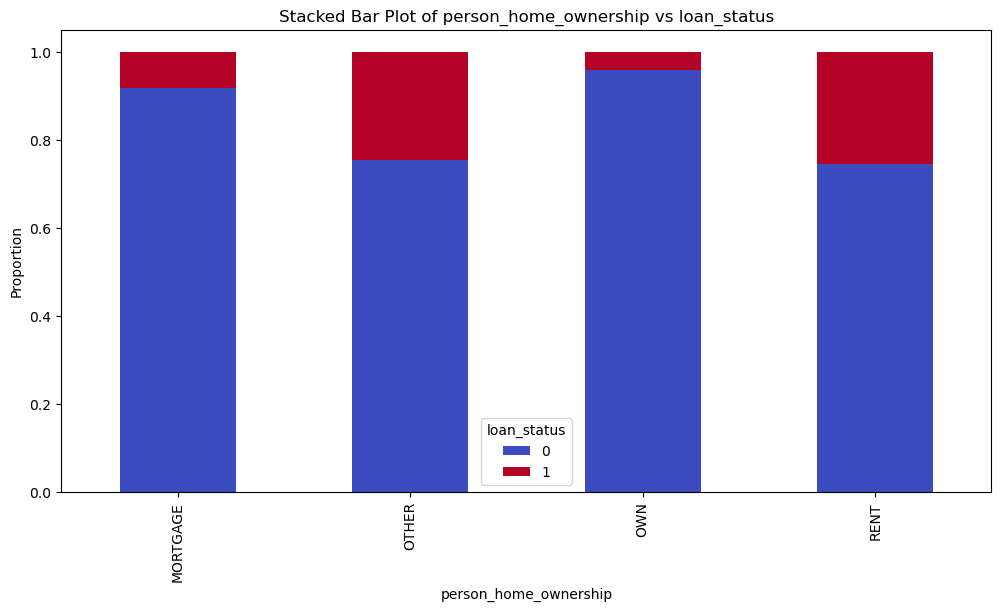

In [22]:
stacked_bar_plot(df_train, 'person_home_ownership')

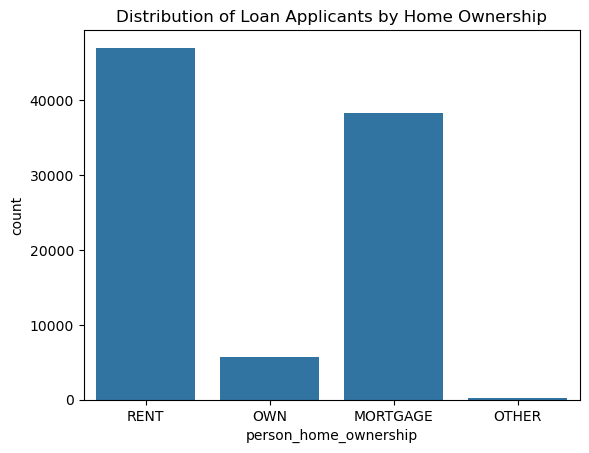

In [23]:
sns.countplot(data=df_train, x='person_home_ownership')
plt.title('Distribution of Loan Applicants by Home Ownership')
plt.show()

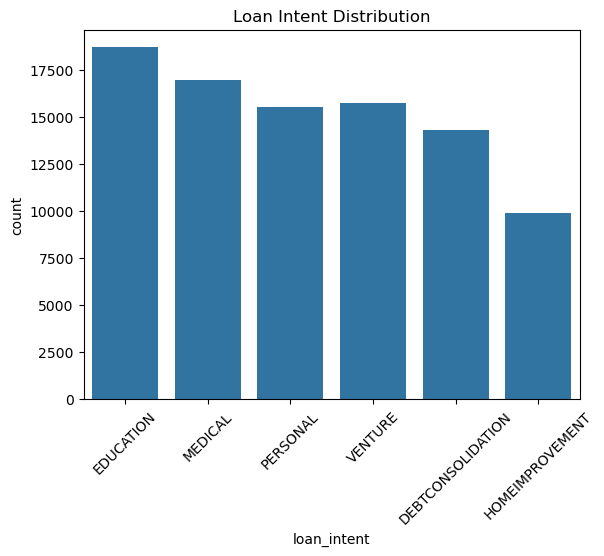

In [24]:
sns.countplot(data=df_train, x='loan_intent')
plt.title('Loan Intent Distribution')
plt.xticks(rotation=45)
plt.show()

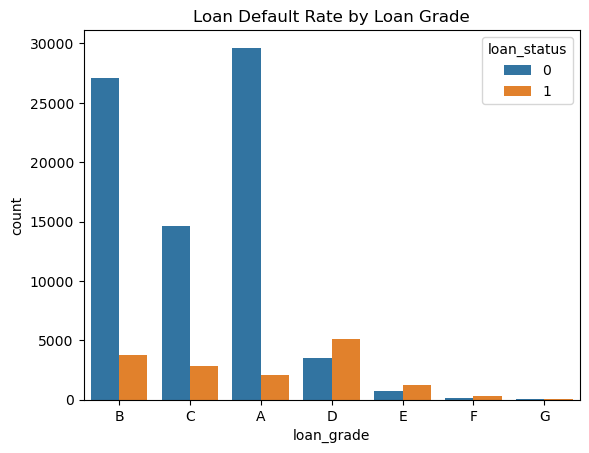

In [25]:
sns.countplot(data=df_train, x='loan_grade', hue='loan_status')
plt.title('Loan Default Rate by Loan Grade')
plt.show()

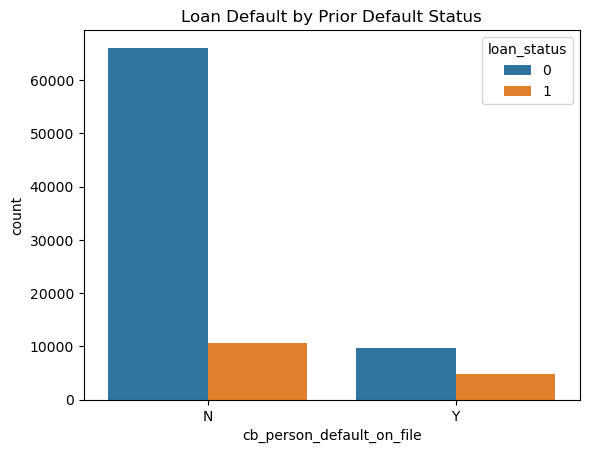

In [26]:
sns.countplot(data=df_train, x='cb_person_default_on_file', hue='loan_status')
plt.title('Loan Default by Prior Default Status')
plt.show()

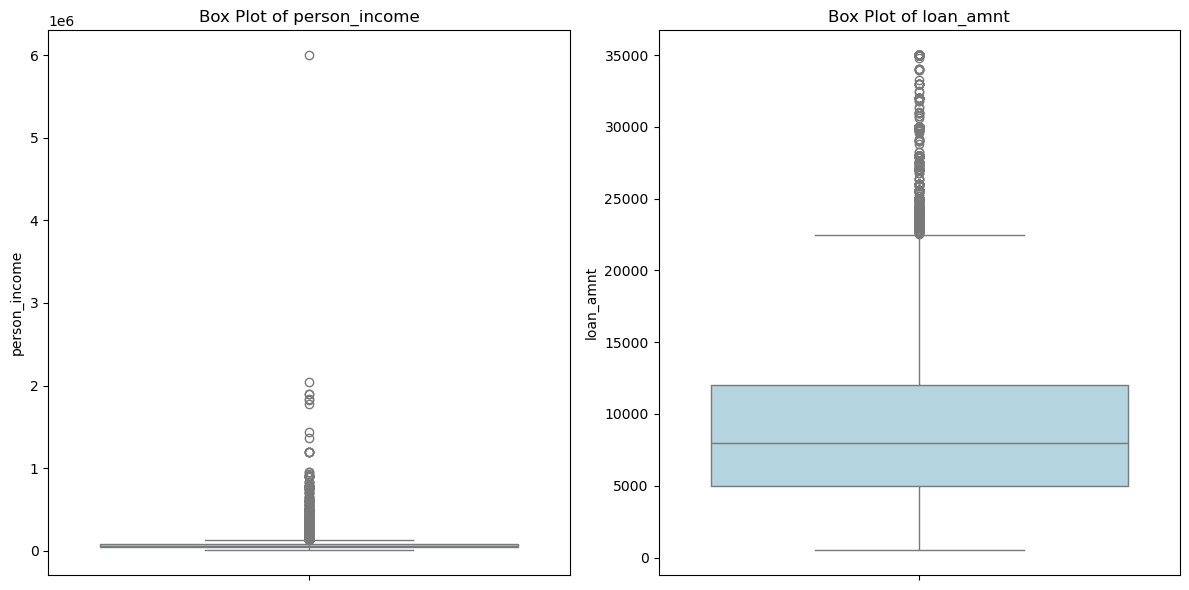

In [27]:
def plot_boxplots(df, columns):
    plt.figure(figsize=(12, 6))
    for i, col in enumerate(columns, 1):
        plt.subplot(1, len(columns), i)
        sns.boxplot(y=df[col], color='lightblue')
        plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()

plot_boxplots(df_train, ['person_income', 'loan_amnt'])

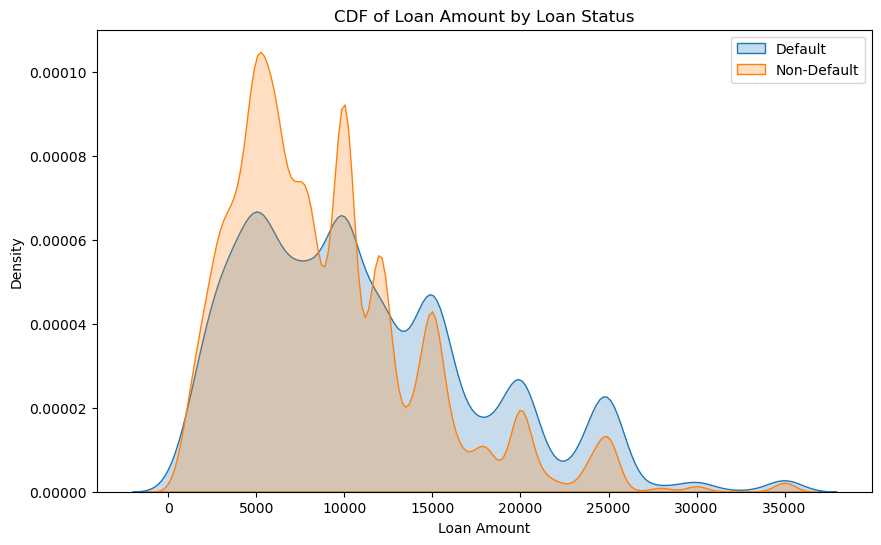

In [28]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train[df_train['loan_status'] == 1]['loan_amnt'], label='Default', fill=True)
sns.kdeplot(df_train[df_train['loan_status'] == 0]['loan_amnt'], label='Non-Default', fill=True)
plt.title('CDF of Loan Amount by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

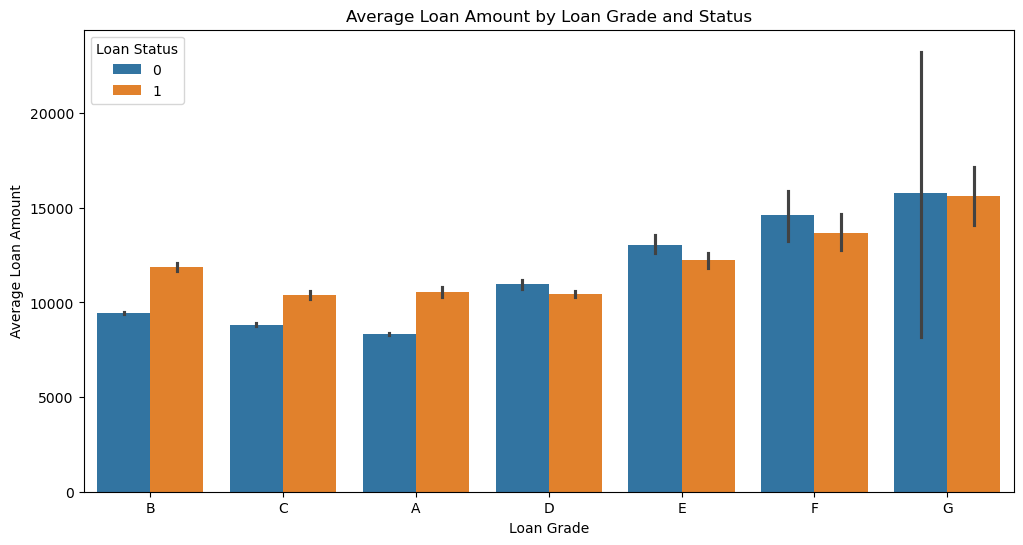

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(x='loan_grade', y='loan_amnt', hue='loan_status', data=df_train, estimator=np.mean)
plt.title('Average Loan Amount by Loan Grade and Status')
plt.xlabel('Loan Grade')
plt.ylabel('Average Loan Amount')
plt.legend(title='Loan Status')
plt.show()

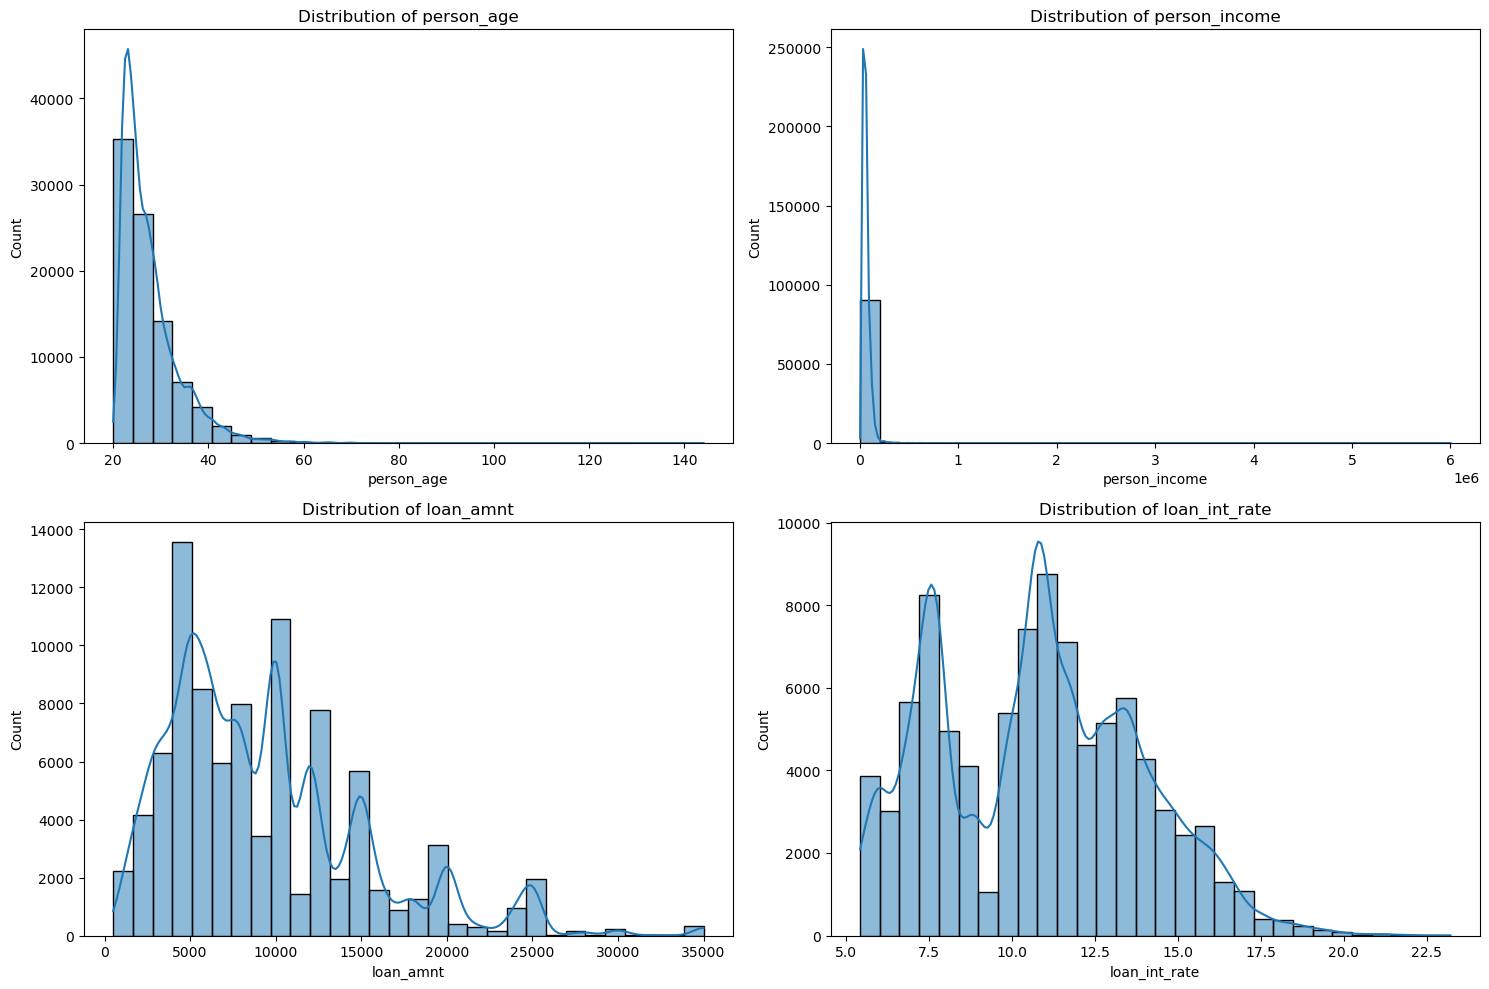

In [30]:
num_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_train[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

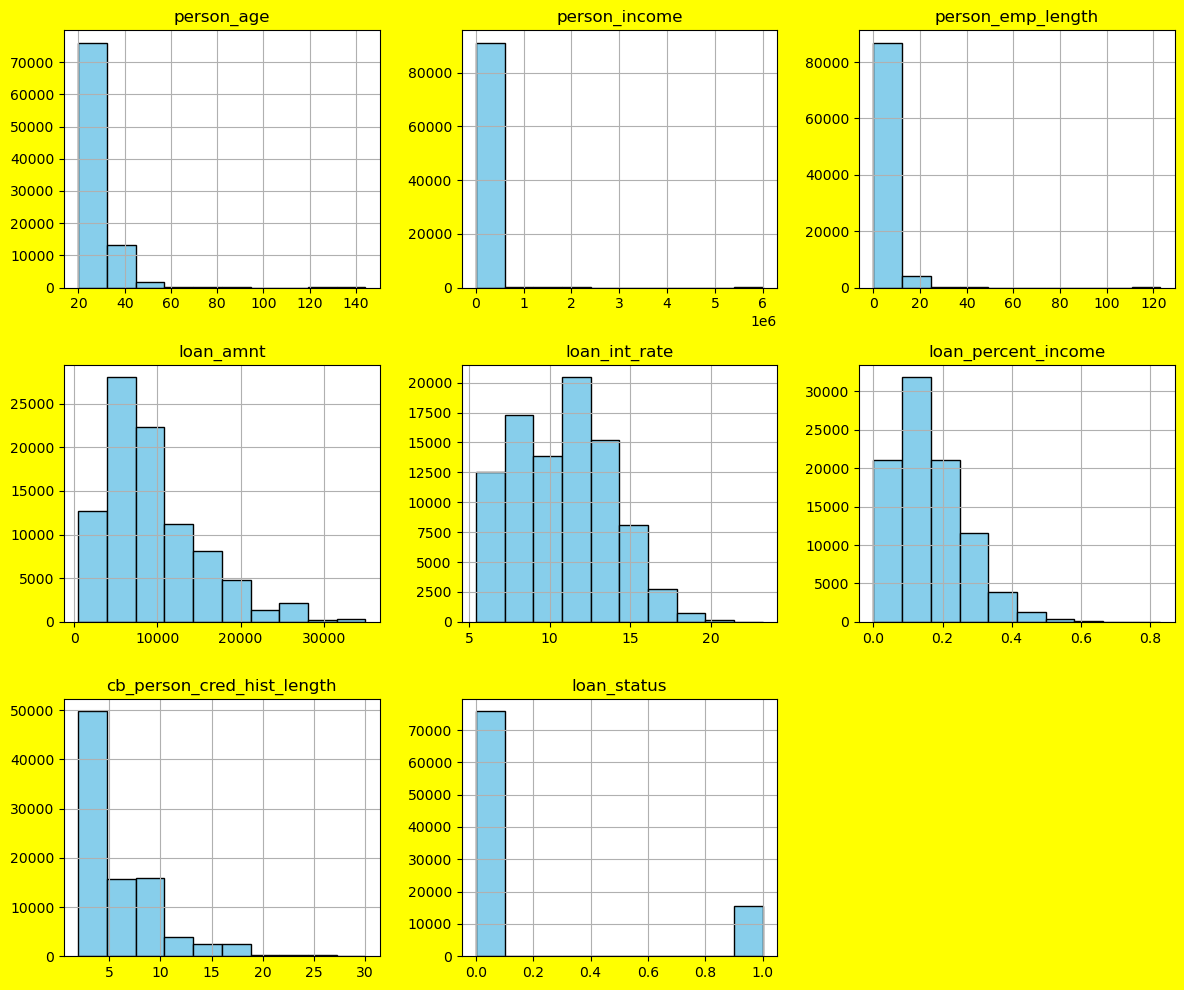

In [31]:
df_train.hist(figsize=(12, 10), color='skyblue', edgecolor='black')
plt.gcf().set_facecolor('yellow')
plt.tight_layout()
plt.show()

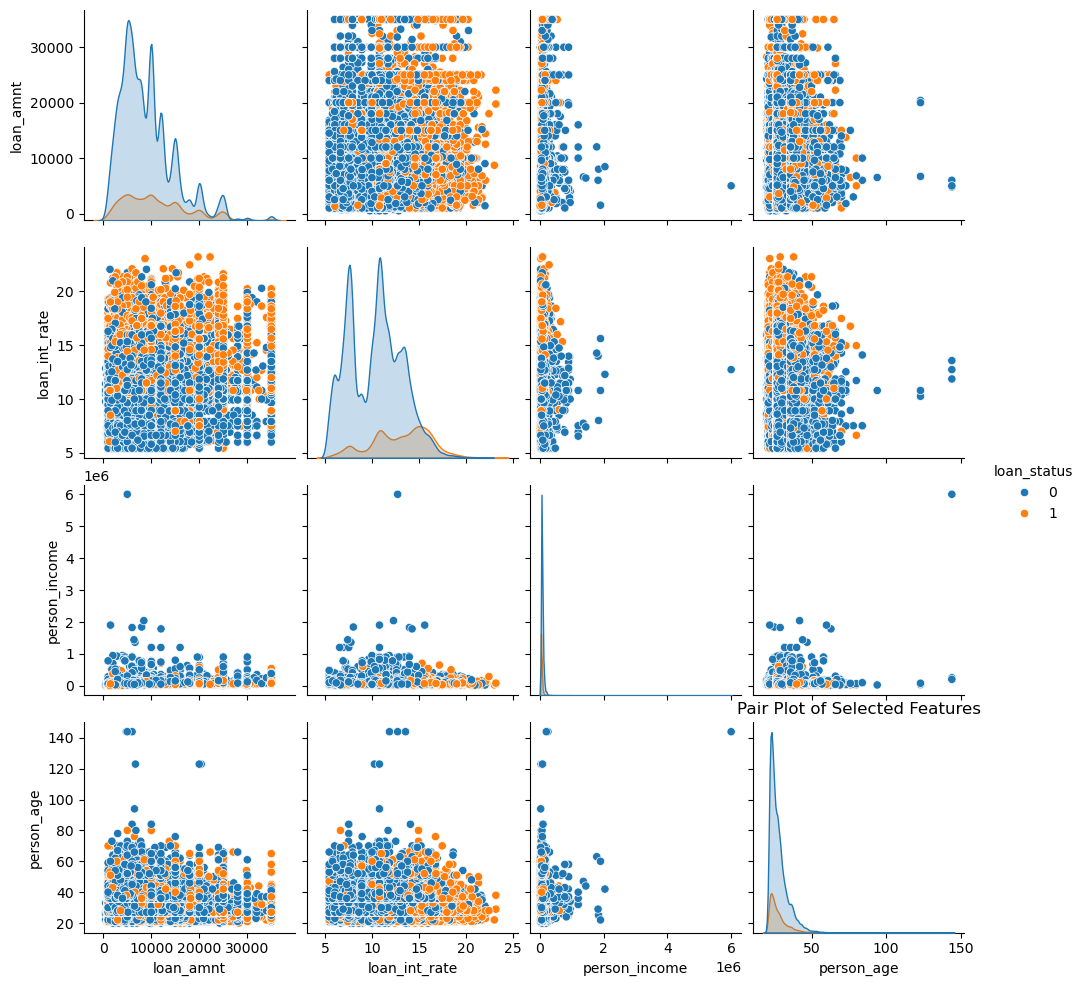

In [32]:
subset_features = ['loan_amnt', 'loan_int_rate', 'person_income', 'person_age', 'loan_status']
sns.pairplot(df_train[subset_features], hue='loan_status')
plt.title('Pair Plot of Selected Features')
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df_train, df_test):  
    label_enc = LabelEncoder()   
    label_cols = ['person_home_ownership', 'loan_grade', 'cb_person_default_on_file']    
    for col in label_cols:
        df_train[col] = label_enc.fit_transform(df_train[col])
        df_test[col] = label_enc.transform(df_test[col])    
    df_train = pd.get_dummies(df_train, columns=['loan_intent'], drop_first=True)
    df_test = pd.get_dummies(df_test, columns=['loan_intent'], drop_first=True) 
    target_col = 'loan_status'
    train_columns = df_train.drop(columns=[target_col]).columns    
    df_test = df_test.reindex(columns=train_columns, fill_value=0)    
    return df_train, df_test
df_train_processed, df_test_processed = preprocess_data(df_train, df_test)

In [34]:
df_train = df_train_processed
df_test = df_test_processed

In [35]:
df_train.shape,df_test.shape

((91226, 16), (39098, 15))

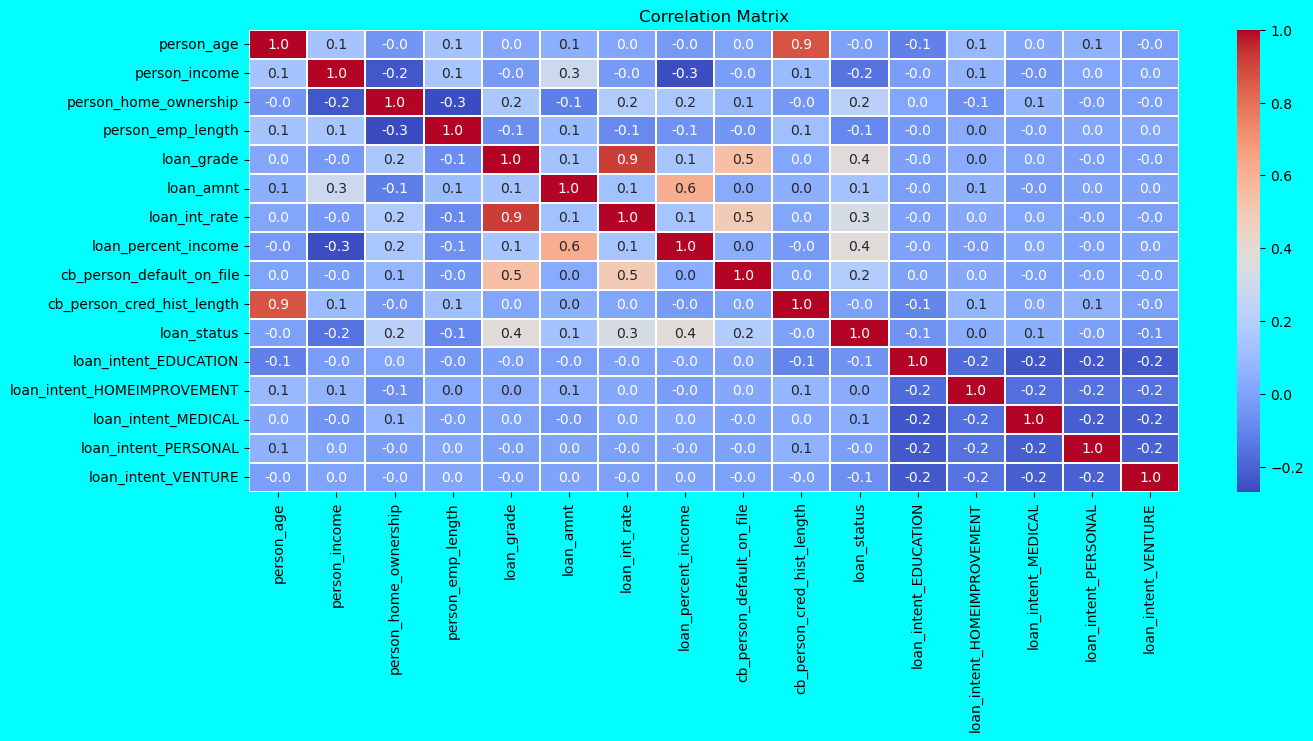

In [36]:
correlation_matrix = df_train.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.2)
plt.gcf().set_facecolor('#00FFFF')  
plt.title('Correlation Matrix')
plt.show()

In [37]:
df_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='object')

In [38]:
df_test.isnull().sum()

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
dtype: int64

In [39]:
def feature_engineering(df):
    
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']  
    df['financial_burden'] = df['loan_amnt'] * df['loan_int_rate'] 
    df['income_per_year_emp'] = df['person_income'] / (df['person_emp_length'])
    df['cred_hist_to_age_ratio'] = df['cb_person_cred_hist_length'] / df['person_age']
    df['int_to_loan_ratio'] = df['loan_int_rate'] / df['loan_amnt']
    df['loan_int_emp_interaction'] = df['loan_int_rate'] * df['person_emp_length']
    df['debt_to_credit_ratio'] = df['loan_amnt'] / df['cb_person_cred_hist_length'] 
    df['int_to_cred_hist'] = df['loan_int_rate'] / df['cb_person_cred_hist_length']  
    df['int_per_year_emp'] = df['loan_int_rate'] / (df['person_emp_length'])
    df['loan_amt_per_emp_year'] = df['loan_amnt'] / (df['person_emp_length'])      
    df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt'] 
    
    return df

#median_income = df_train['person_income'].median()
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)

In [40]:
y = df_train['loan_status'] 
df_train = df_train.drop(['loan_status'],axis=1)
X = df_train

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train_data = df_train
scaled_test_data = df_test

In [42]:
pip install --upgrade lightgbm


Note: you may need to restart the kernel to use updated packages.


In [43]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import roc_auc_score

lgb_params = {
    'objective': 'binary',
    'n_estimators': 3000,
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.0322942967545754,
    'num_leaves': 24,
    'max_depth': 15,
    'min_data_in_leaf': 25,  
    'feature_fraction': 0.6236144085285287, 
    'bagging_fraction': 0.9596685778433888, 
    'bagging_freq': 3  
}

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
lgbm_predictions = np.zeros(len(scaled_train_data))
lgbm_true_labels = np.zeros(len(scaled_train_data))
lgbm_test_predictions = np.zeros(len(scaled_test_data))

for fold, (train_idx, val_idx) in enumerate(skf.split(scaled_train_data, y)):
    X_train, X_val = scaled_train_data.iloc[train_idx].values, scaled_train_data.iloc[val_idx].values
    y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values    

    lgbm_model = LGBMClassifier(**lgb_params)
    lgbm_model.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)],
                   eval_metric='auc',
                   callbacks=[early_stopping(10), log_evaluation(False)])  # Corrected for LightGBM 4.6.0    

    lgbm_fold_preds = lgbm_model.predict_proba(X_val)[:, 1]  
    lgbm_fold_test_preds = lgbm_model.predict_proba(scaled_test_data)[:, 1]   
    lgbm_predictions[val_idx] = lgbm_fold_preds
    lgbm_true_labels[val_idx] = y_val    
    lgbm_test_predictions += lgbm_fold_test_preds / n_splits

overall_metric_lgbm = roc_auc_score(lgbm_true_labels, lgbm_predictions)
print("Overall AUC (LGBMClassifier with StratifiedKFold):", overall_metric_lgbm)


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, su

In [44]:
catboost_params = {
    'depth': 7,
    'learning_rate': 0.19893301995319765,
    'bagging_temperature': 0.7979373495258176,
    'l2_leaf_reg': 5,
    'loss_function': 'Logloss',
    'iterations': 400,
    'grow_policy': 'Lossguide',
    'eval_metric': 'AUC',
}

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

catboost_predictions = np.zeros(len(scaled_train_data))
catboost_true_labels = np.zeros(len(scaled_train_data))
catboost_test_predictions = np.zeros(len(scaled_test_data))

for fold, (train_idx, val_idx) in enumerate(skf.split(scaled_train_data, y)):
    X_train, X_val = scaled_train_data.iloc[train_idx], scaled_train_data.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    catboost_model = CatBoostClassifier(**catboost_params)
    catboost_model.fit(X_train, y_train,
                       eval_set=(X_val, y_val),
                       early_stopping_rounds=10,
                       verbose=True)
  
    catboost_fold_preds = catboost_model.predict_proba(X_val)[:, 1]  
    catboost_fold_test_preds = catboost_model.predict_proba(scaled_test_data)[:, 1]  
    catboost_predictions[val_idx] = catboost_fold_preds
    catboost_true_labels[val_idx] = y_val    
    catboost_test_predictions += catboost_fold_test_preds / n_splits
overall_metric_catboost = roc_auc_score(catboost_true_labels, catboost_predictions)
print("Overall AUC (CatBoostClassifier with StratifiedKFold):", overall_metric_catboost)

0:	test: 0.8511688	best: 0.8511688 (0)	total: 156ms	remaining: 1m 2s
1:	test: 0.8578288	best: 0.8578288 (1)	total: 169ms	remaining: 33.7s
2:	test: 0.8798502	best: 0.8798502 (2)	total: 183ms	remaining: 24.3s
3:	test: 0.8988666	best: 0.8988666 (3)	total: 198ms	remaining: 19.6s
4:	test: 0.9066845	best: 0.9066845 (4)	total: 212ms	remaining: 16.7s
5:	test: 0.9155118	best: 0.9155118 (5)	total: 227ms	remaining: 14.9s
6:	test: 0.9158664	best: 0.9158664 (6)	total: 241ms	remaining: 13.6s
7:	test: 0.9249141	best: 0.9249141 (7)	total: 256ms	remaining: 12.6s
8:	test: 0.9259767	best: 0.9259767 (8)	total: 271ms	remaining: 11.8s
9:	test: 0.9298488	best: 0.9298488 (9)	total: 286ms	remaining: 11.1s
10:	test: 0.9312738	best: 0.9312738 (10)	total: 302ms	remaining: 10.7s
11:	test: 0.9326235	best: 0.9326235 (11)	total: 318ms	remaining: 10.3s
12:	test: 0.9328330	best: 0.9328330 (12)	total: 333ms	remaining: 9.91s
13:	test: 0.9348778	best: 0.9348778 (13)	total: 349ms	remaining: 9.61s
14:	test: 0.9371712	best: 

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

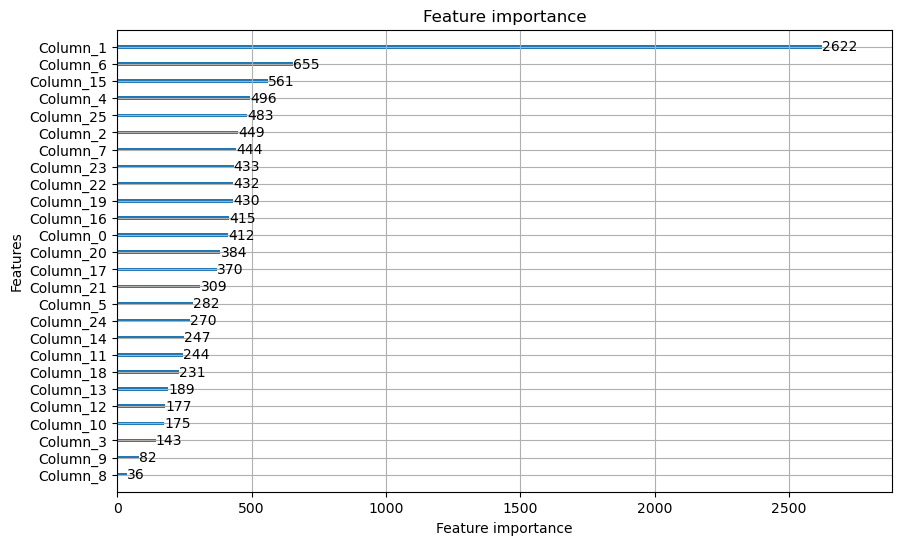

In [45]:
from lightgbm import plot_importance
plot_importance(lgbm_model,figsize=(10, 6))

In [46]:
lgbm_model

LGBMClassifier(bagging_fraction=0.9596685778433888, bagging_freq=3,
               feature_fraction=0.6236144085285287,
               learning_rate=0.0322942967545754, max_depth=15,
               metric='binary_logloss', min_data_in_leaf=25, n_estimators=3000,
               num_leaves=24, objective='binary', random_state=42)

In [47]:
!pip install lime

In [48]:
import lime
import lime.lime_tabular

In [49]:
df_train.shape

(91226, 26)

In [50]:
df_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,financial_burden,income_per_year_emp,cred_hist_to_age_ratio,int_to_loan_ratio,loan_int_emp_interaction,debt_to_credit_ratio,int_to_cred_hist,int_per_year_emp,loan_amt_per_emp_year,income_to_loan_ratio
0,37,35000,3,0.0,1,6000,11.49,0.17,0,14,...,68940.0,inf,0.378378,0.001915,0.00,428.571429,0.820714,inf,inf,5.833333
1,22,56000,2,6.0,2,4000,13.35,0.07,0,2,...,53400.0,9.333333e+03,0.090909,0.003337,80.10,2000.000000,6.675000,2.225000,666.666667,14.000000
2,29,28800,2,8.0,0,6000,8.90,0.21,0,10,...,53400.0,3.600000e+03,0.344828,0.001483,71.20,600.000000,0.890000,1.112500,750.000000,4.800000
3,30,70000,3,14.0,1,12000,11.11,0.17,0,5,...,133320.0,5.000000e+03,0.166667,0.000926,155.54,2400.000000,2.222000,0.793571,857.142857,5.833333
4,22,60000,3,2.0,0,6000,6.92,0.10,0,3,...,41520.0,3.000000e+04,0.136364,0.001153,13.84,2000.000000,2.306667,3.460000,3000.000000,10.000000


In [51]:
df_test.shape

(39098, 26)

In [52]:
#rows_with_inf = df_test[np.isinf(df_test).any(axis=1)]
#print("Rows with infinity values:")
#rows_with_inf

In [53]:
df_train.replace([np.inf, -np.inf], np.nan, inplace=True)
df_train.fillna(df_train.mean(), inplace=True)
print("DataFrame after replacing inf with column means:")
df_train.head()

DataFrame after replacing inf with column means:


,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,financial_burden,income_per_year_emp,cred_hist_to_age_ratio,int_to_loan_ratio,loan_int_emp_interaction,debt_to_credit_ratio,int_to_cred_hist,int_per_year_emp,loan_amt_per_emp_year,income_to_loan_ratio
0,37,35000,3,0.0,1,6000,11.49,0.17,0,14,...,68940.0,19519.454848,0.378378,0.001915,0.00,428.571429,0.820714,3.451274,2878.295562,5.833333
1,22,56000,2,6.0,2,4000,13.35,0.07,0,2,...,53400.0,9333.333333,0.090909,0.003337,80.10,2000.000000,6.675000,2.225000,666.666667,14.000000
2,29,28800,2,8.0,0,6000,8.90,0.21,0,10,...,53400.0,3600.000000,0.344828,0.001483,71.20,600.000000,0.890000,1.112500,750.000000,4.800000
3,30,70000,3,14.0,1,12000,11.11,0.17,0,5,...,133320.0,5000.000000,0.166667,0.000926,155.54,2400.000000,2.222000,0.793571,857.142857,5.833333
4,22,60000,3,2.0,0,6000,6.92,0.10,0,3,...,41520.0,30000.000000,0.136364,0.001153,13.84,2000.000000,2.306667,3.460000,3000.000000,10.000000


In [54]:
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.fillna(df_test.mean(), inplace=True)
print("DataFrame after replacing inf with column means:")
df_test.head()

DataFrame after replacing inf with column means:


,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,financial_burden,income_per_year_emp,cred_hist_to_age_ratio,int_to_loan_ratio,loan_int_emp_interaction,debt_to_credit_ratio,int_to_cred_hist,int_per_year_emp,loan_amt_per_emp_year,income_to_loan_ratio
0,23,69000,3,3.0,5,25000,15.76,0.36,0,2,...,394000.0,23000.0,0.086957,0.000630,47.28,12500.0,7.880000,5.253333,8333.333333,2.760000
1,26,96000,0,6.0,2,10000,12.68,0.10,1,4,...,126800.0,16000.0,0.153846,0.001268,76.08,2500.0,3.170000,2.113333,1666.666667,9.600000
2,26,30000,3,5.0,4,4000,17.19,0.13,1,2,...,68760.0,6000.0,0.076923,0.004298,85.95,2000.0,8.595000,3.438000,800.000000,7.500000
3,33,50000,3,4.0,0,7000,8.90,0.14,0,7,...,62300.0,12500.0,0.212121,0.001271,35.60,1000.0,1.271429,2.225000,1750.000000,7.142857
4,26,102000,0,8.0,3,15000,16.32,0.15,1,4,...,244800.0,12750.0,0.153846,0.001088,130.56,3750.0,4.080000,2.040000,1875.000000,6.800000


In [55]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(X_train.mean())
X = X_train.values

explainer = lime.lime_tabular.LimeTabularExplainer(X, 
                                                   feature_names=X_train.columns, 
                                                   class_names=['0', '1'], 
                                                   kernel_width=5)


In [56]:
redict_fn_lgb = lambda x: lgbm_model.predict_proba(x).astype(float)
#X = X_train.values
#explainer = lime.lime_tabular.LimeTabularExplainer(X,feature_names = X_train.columns,class_names=['0','1'],kernel_width=5)

In [57]:
choosen_instance = X_val.loc[[32558]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_lgb,num_features=15)
exp.show_in_notebook(show_all=False)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


In [58]:
choosen_instance = X_val.loc[[32562]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_lgb,num_features=15)
exp.show_in_notebook(show_all=False)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


In [59]:
choosen_instance = X_val.loc[[25]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_lgb,num_features=15)
exp.show_in_notebook(show_all=False)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


In [60]:
choosen_instance = X_val.loc[[10]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_lgb,num_features=15)
exp.show_in_notebook(show_all=False)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.6236144085285287, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6236144085285287
[LightGBM] [Warning] bagging_fraction is set=0.9596685778433888, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9596685778433888
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


In [61]:
df_sub.head()

,id,loan_status
0,58645,0.5
1,58646,0.5
2,58647,0.5
3,58648,0.5
4,58649,0.5


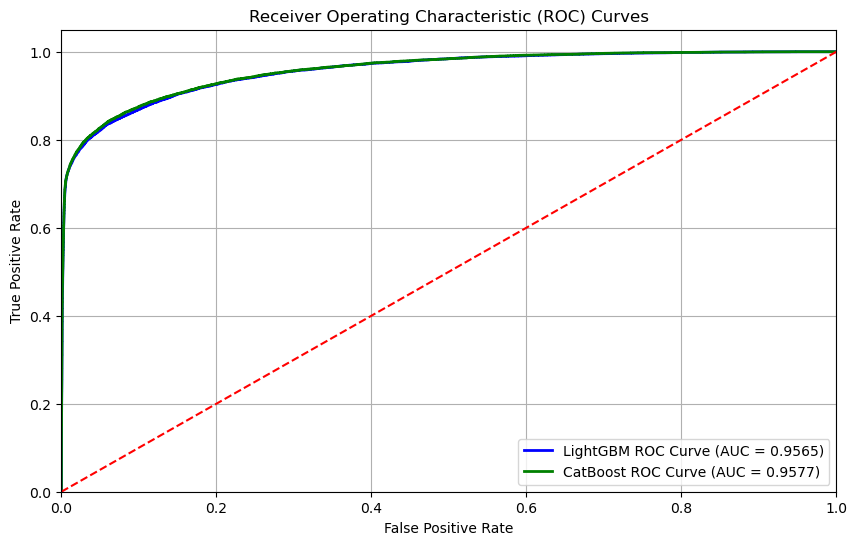

In [62]:
from sklearn.metrics import roc_curve, auc
fpr_lgbm, tpr_lgbm, _ = roc_curve(lgbm_true_labels, lgbm_predictions)
roc_auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

fpr_catboost, tpr_catboost, _ = roc_curve(catboost_true_labels, catboost_predictions)
roc_auc_catboost = auc(fpr_catboost, tpr_catboost)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lgbm, tpr_lgbm, color='blue', lw=2, label=f'LightGBM ROC Curve (AUC = {roc_auc_lgbm:.4f})')
plt.plot(fpr_catboost, tpr_catboost, color='green', lw=2, label=f'CatBoost ROC Curve (AUC = {roc_auc_catboost:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [63]:
df_sub['loan_status'] = lgbm_test_predictions*0.2 + catboost_test_predictions*0.8 #+ xgb_test_predictions*0.0

In [64]:
df_sub.head()

,id,loan_status
0,58645,0.998974
1,58646,0.038293
2,58647,0.553741
3,58648,0.013063
4,58649,0.068351


In [65]:
df_sub.to_csv('submission.csv', index=False)